## Kode til FN's verdensmål


# Load packages

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import plotly.express as px

from tools import *
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# Set global plot styles
plt.rcParams['xtick.labelsize'] = 12   # X-axis tick labels
plt.rcParams['ytick.labelsize'] = 12   # Y-axis tick labels
plt.rcParams['axes.titlesize'] = 14    # Title
plt.rcParams['axes.labelsize'] = 13    # Axis labels
plt.rcParams['legend.fontsize'] = 10   # Legend

# Load data

### Link to data on goals: https://dashboards.sdgindex.org/downloads/
### Link to data on population: https://data.worldbank.org/indicator/SP.POP.TOTL?end=2024&name_desc=false&start=2000&utm_source=chatgpt.com

In [4]:
# --- Load SDG Index data ---
data_path = r"../data/full_data_set.xlsx"
df = pd.read_excel(data_path, sheet_name="Backdated SDG Index")

# Remove aggregates (ids starting with "_")
df = df[~df["id"].astype(str).str.startswith("_")].copy()

# --- Clean numeric columns (sdgi_s + goals) ---
goal_cols = [c for c in df.columns if c.startswith("goal")]
all_cols = ["sdgi_s"] + goal_cols
for col in all_cols:
    df[col] = df[col].astype(str).str.replace(",", ".").astype(float)

# --- Load population data ---
population_path = r"../data/population_data.xlsx"
df_pop = pd.read_excel(population_path, sheet_name="DATA")

# Reshape into long format
df_pop_long = df_pop.melt(
    id_vars=["Country Name", "Country Code"],
    var_name="year",
    value_name="population"
)
df_pop_long["year"] = pd.to_numeric(df_pop_long["year"], errors="coerce")

start_year, end_year = 2000, 2024

# Extract 2024 only
pop_2024 = df_pop_long[df_pop_long["year"] == end_year][["Country Code", "population"]]

# Split into start and end year
df_start = df[df["year"] == start_year].set_index("id")[all_cols+ ["indexreg_"]]
df_end   = df[df["year"] == end_year].set_index("id")[all_cols]

# --- Build structured DataFrame ---
summary = pd.DataFrame(index=df_start.index)

for col in all_cols:
    summary[f"{col}_start"] = df_start[col]
    summary[f"{col}_rel_change"] = (
        (df_end[col] - df_start[col])
    )
    
summary["region"] = df_start["indexreg_"]

# Add population
summary = summary.reset_index().merge(
    pop_2024, left_on="id", right_on="Country Code", how="left"
).drop(columns=["Country Code"])

# Force population to float immediately
summary["population"] = pd.to_numeric(summary["population"], errors="coerce").astype(float)

summary = summary.set_index("id")

# Build stable region → code mapping from the full dataset
region_categories = pd.Categorical(summary["region"].dropna()).categories
region_to_code = {region: i for i, region in enumerate(region_categories)}

summary

,sdgi_s_start,sdgi_s_rel_change,goal1_start,goal1_rel_change,goal2_start,goal2_rel_change,goal3_start,goal3_rel_change,goal4_start,goal4_rel_change,...,goal14_start,goal14_rel_change,goal15_start,goal15_rel_change,goal16_start,goal16_rel_change,goal17_start,goal17_rel_change,region,population
id,,,,,,,,,,,,,,,,,,,,,
AFG,34.876604,14.225787,19.8700,-4.1785,24.198750,9.313875,20.144857,16.937786,1.642500,39.728000,...,NaN,NaN,45.24850,26.728250,41.161909,-1.328273,47.122333,4.884667,E_Euro_Asia,42647492.0
AGO,46.855637,5.915096,37.7055,-5.4375,44.070556,6.343889,20.548214,18.532786,44.220000,12.300250,...,68.079333,-0.942833,62.30480,4.092400,37.739727,3.510545,69.525833,-6.671000,Africa,37885849.0
ALB,66.484883,8.673677,87.2610,11.4155,47.877875,11.224250,74.785643,8.513857,83.763500,5.458500,...,31.083200,14.156000,67.74260,14.371600,70.799545,-6.457909,67.454667,4.346167,E_Euro_Asia,2714617.0
AND,69.534100,10.365754,NaN,NaN,91.095800,-2.718200,91.811600,4.185800,52.375667,44.117667,...,NaN,NaN,64.41600,7.233667,87.778800,-12.569000,54.791600,3.039200,W_Europe,81938.0
ARE,59.339616,10.500368,99.8270,-0.5915,71.851667,-5.151889,81.794154,10.457923,78.903500,20.930500,...,65.411500,6.712667,30.57325,24.457000,70.844800,-0.881100,52.840667,0.636167,MENA,10876981.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WSM,64.032252,3.636636,75.2465,20.0175,57.575750,-1.652375,63.768500,3.747417,73.121250,-1.504500,...,81.253200,-13.117400,40.33350,3.441500,80.234500,-5.430667,67.325833,10.445333,Oceania,218019.0
YEM,47.513751,0.227312,61.7775,-61.0820,41.250667,-8.609222,35.150714,11.188857,24.041000,4.800750,...,50.659000,24.450333,44.72500,5.755500,45.805286,-4.511286,68.080000,-9.071600,MENA,40583164.0
ZAF,56.271581,7.842728,33.7595,18.1835,51.570222,1.001222,41.684571,15.867214,55.710500,27.867500,...,64.002333,6.050500,56.73800,3.787400,55.173818,-1.702909,69.835833,10.349500,Africa,64007187.0


# Figurer til resultat afsnit
<!-- 
- **<span style="color:blue; font-size:18px">color_by_region = True</span>** → color dots by region  
- **<span style="color:blue; font-size:18px">scale_by_population = True</span>** → set marker sizes according to nation population  
- **<span style="color:blue; font-size:18px">show_weighted = True</span>** → add the weighted OLS estimate   -->


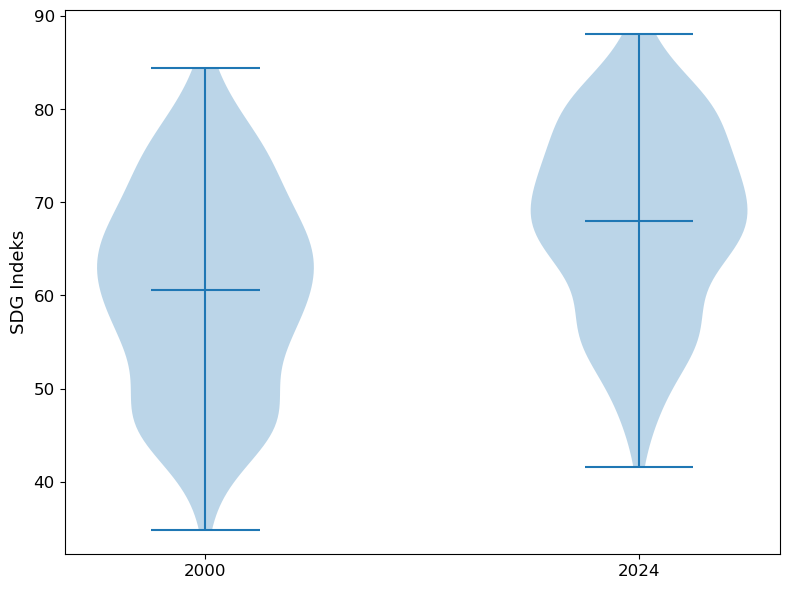

In [5]:
# Violin plot of SDG Index in 2000 and 2024
df_2000 = df[df["year"] == 2000]
df_2024 = df[df["year"] == 2024]

sdgi_2000 = df_2000["sdgi_s"].dropna()
sdgi_2024 = df_2024["sdgi_s"].dropna()

plt.figure(figsize=(8, 6))
plt.violinplot([sdgi_2000, sdgi_2024], showmeans=True, showextrema=True,
               )

plt.xticks([1, 2], ["2000", "2024"])
plt.ylabel("SDG Indeks")
plt.tight_layout()

plt.show()


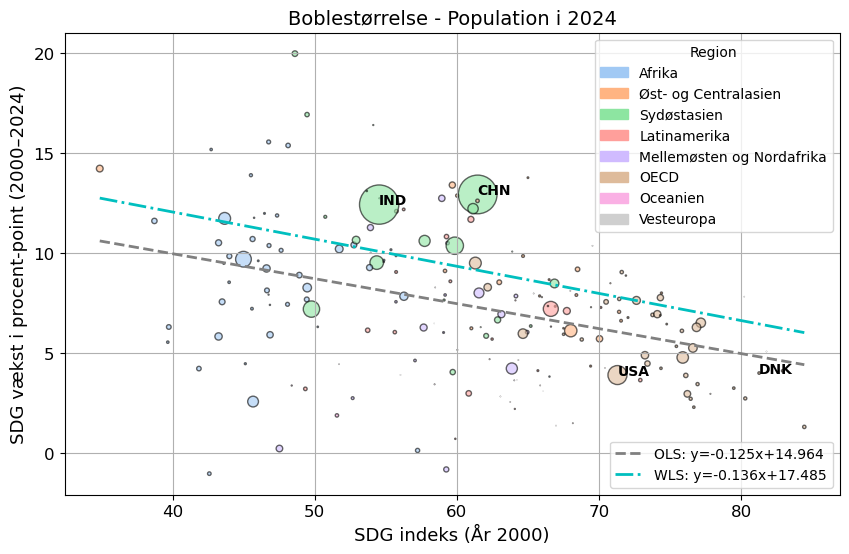

In [6]:
# Get all region categories from your summary
region_categories = pd.Categorical(summary["region"].dropna()).categories

# Assign consistent pastel colors
pastel_palette = sns.color_palette("pastel", len(region_categories))
region_to_color = dict(zip(region_categories, pastel_palette))

plot_growth_vs_initial(summary, goal="sdgi_s",
                       highlight_ids=["CHN","IND","USA","DNK"],
                       region_to_code=region_to_code,
                       region_categories=region_categories,
                       region_to_color=region_to_color,
                       color_by_region=True,
                       scale_by_population=True,
                       show_weighted=True,
                       show_confidence_bands=False,)

In [7]:
# hvilke lande har negativ SDG vækst?
summary[summary.sdgi_s_rel_change < 0]

,sdgi_s_start,sdgi_s_rel_change,goal1_start,goal1_rel_change,goal2_start,goal2_rel_change,goal3_start,goal3_rel_change,goal4_start,goal4_rel_change,...,goal14_start,goal14_rel_change,goal15_start,goal15_rel_change,goal16_start,goal16_rel_change,goal17_start,goal17_rel_change,region,population
id,,,,,,,,,,,,,,,,,,,,,
SSD,42.583215,-1.028768,65.9180,-65.9180,26.915571,0.088143,21.601143,7.901000,0.62100,1.23225,...,NaN,NaN,64.0115,4.20625,48.405600,-5.335400,45.3386,-1.8090,Africa,11943408.0
SYR,59.249321,-0.817847,82.1615,-51.7785,51.979444,-18.359000,65.964071,-1.879857,58.01775,-8.87075,...,44.6784,3.5976,56.4718,0.56200,55.724167,-1.247167,53.1838,3.0394,MENA,24672760.0


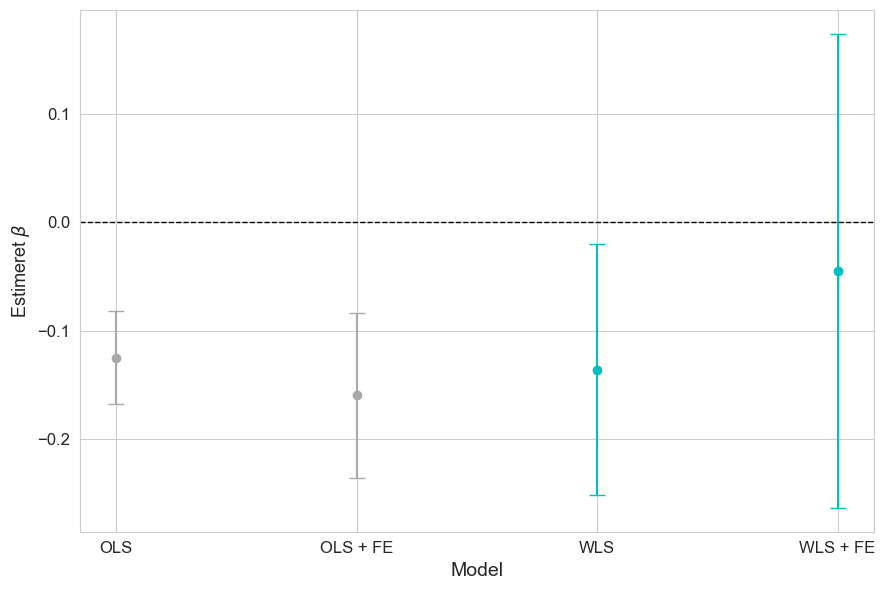

In [8]:

# Prepare data
df = summary[['sdgi_s_start', 'sdgi_s_rel_change', 'region', 'population']].dropna()
df['sdgi_s_start'] = pd.to_numeric(df['sdgi_s_start'], errors='coerce')
df['sdgi_s_rel_change'] = pd.to_numeric(df['sdgi_s_rel_change'], errors='coerce')
df['population'] = pd.to_numeric(df['population'], errors='coerce')
df = df.dropna(subset=['sdgi_s_start', 'sdgi_s_rel_change', 'population'])

# Within transformation for FE
df['sdgi_s_start_within'] = df['sdgi_s_start'] - df.groupby('region')['sdgi_s_start'].transform('mean')
df['sdgi_s_rel_change_within'] = df['sdgi_s_rel_change'] - df.groupby('region')['sdgi_s_rel_change'].transform('mean')

# Define regressions with robust SE
regressions = {
    'OLS': sm.OLS(df['sdgi_s_rel_change'], sm.add_constant(df['sdgi_s_start'])).fit(cov_type='HC3'),
    'OLS + FE': sm.OLS(df['sdgi_s_rel_change_within'], sm.add_constant(df['sdgi_s_start_within'])).fit(cov_type='HC3'),
    'WLS': sm.WLS(df['sdgi_s_rel_change'], sm.add_constant(df['sdgi_s_start']), weights=df['population']).fit(cov_type='HC3'),
    'WLS + FE': sm.WLS(df['sdgi_s_rel_change_within'], sm.add_constant(df['sdgi_s_start_within']), weights=df['population']).fit(cov_type='HC3')
}

# Extract coefficients and robust CI
coef_df = pd.DataFrame([
    {
        'Model': name,
        'Coef': reg.params['sdgi_s_start'] if 'sdgi_s_start' in reg.params else reg.params['sdgi_s_start_within'],
        'CI_low': reg.conf_int().loc['sdgi_s_start', 0] if 'sdgi_s_start' in reg.params else reg.conf_int().loc['sdgi_s_start_within', 0],
        'CI_high': reg.conf_int().loc['sdgi_s_start', 1] if 'sdgi_s_start' in reg.params else reg.conf_int().loc['sdgi_s_start_within', 1]
    }
    for name, reg in regressions.items()
])

# Academic style plot
sns.set_style("whitegrid")
plt.figure(figsize=(9,6))
colors =  ["darkgrey", "darkgrey","c", "c"] # sns.color_palette("tab10", n_colors=len(coef_df))

for i, row in coef_df.iterrows():
    plt.errorbar(row['Model'], row['Coef'], 
                 yerr=[[row['Coef'] - row['CI_low']], [row['CI_high'] - row['Coef']]],
                 fmt='o', color=colors[i], capsize=6)

plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.ylabel(r'Estimeret $\beta$')
plt.xlabel('Model', fontsize=14)
plt.tight_layout()
plt.show()


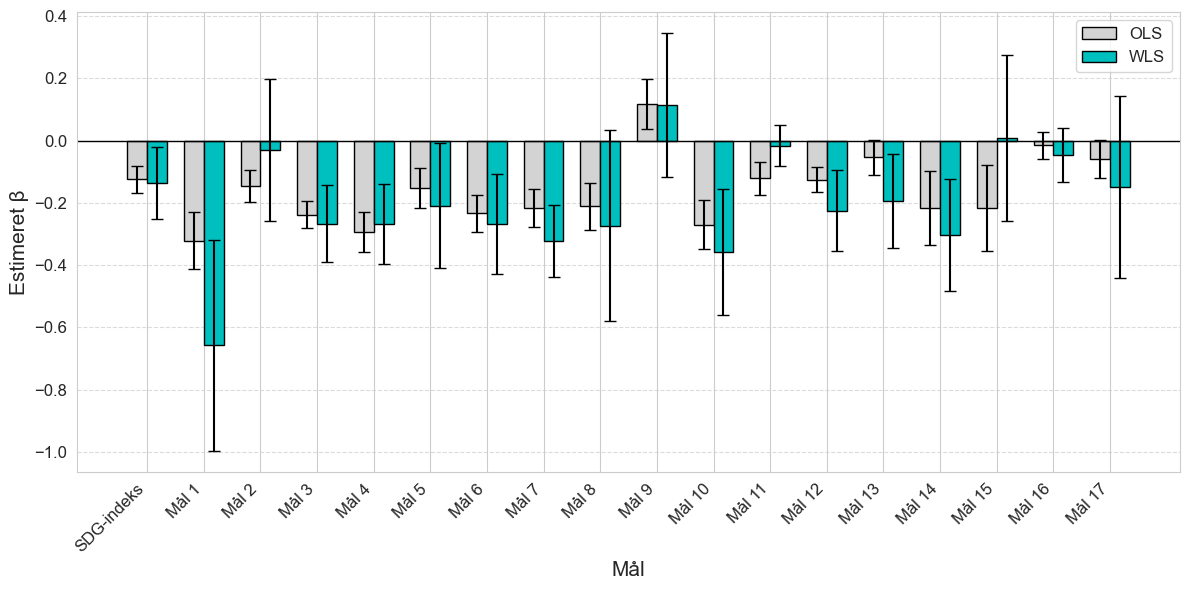

In [9]:
# --- Compute slopes and CI for all goals ---
goal_cols = ["sdgi_s"] + [c for c in summary.columns if c.startswith("goal") and c.endswith("_start")]

results = []
for col in goal_cols:
    goal = col.replace("_start", "")
    res = compute_fit(summary, goal=goal)
    res["Goal"] = goal.upper()
    results.append(res)

df_results = pd.DataFrame(results).set_index("Goal")

# --- Oversæt engelske/tekniske navne til danske labels ---
label_map = {
    "SDGI_S": "SDG-indeks",
    **{f"GOAL{i}": f"Mål {i}" for i in range(1, 18)}
}
df_results.index = df_results.index.map(lambda g: label_map.get(g, g))

# --- Plot with CI error bars ---
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(df_results))
width = 0.35

# OLS søjler + KI
ax.bar(x - width/2, df_results["OLS"], width,
       color="lightgrey", edgecolor="black", label="OLS",
       yerr=[df_results["OLS"] - df_results["OLS_CI_low"],
             df_results["OLS_CI_high"] - df_results["OLS"]],
       capsize=4)

# WLS søjler + KI
ax.bar(x + width/2, df_results["WLS"], width,
       color="c", edgecolor="black", label="WLS",
       yerr=[df_results["WLS"] - df_results["WLS_CI_low"],
             df_results["WLS_CI_high"] - df_results["WLS"]],
       capsize=4)

# Layout
ax.axhline(0, color="black", linewidth=1)
ax.set_ylabel("Estimeret β", fontsize=15)
ax.set_xlabel("Mål", fontsize=15)
ax.set_xticks(x)
ax.set_xticklabels(df_results.index, rotation=45, ha="right", fontsize=12)
ax.tick_params(axis="y", labelsize=12)
ax.legend(fontsize=12)
ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

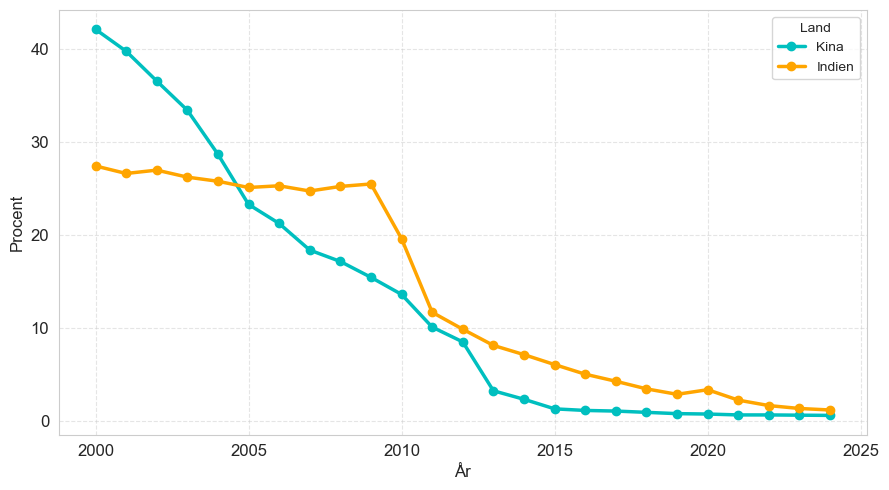

In [10]:
# ---------------------------------------------------------
# 1. Load Excel file
# ---------------------------------------------------------
df = pd.read_excel("../data/data_kina.xlsx")

# Convert decimal commas to points and cast to float
df["Kina"] = df["Kina"].astype(str).str.replace(",", ".").astype(float)
df["Indien"] = df["Indien"].astype(str).str.replace(",", ".").astype(float)

# ---------------------------------------------------------
# 2. Plot
# ---------------------------------------------------------

plt.figure(figsize=(9,5))

# Kina in light grey, Indien in cyan
plt.plot(df["År"], df["Kina"], marker="o", color="c",
         linewidth=2.5, label="Kina")
plt.plot(df["År"], df["Indien"], marker="o", color="orange",
         linewidth=2.5, label="Indien")

# ---------------------------------------------------------
# 3. Style
# ---------------------------------------------------------
plt.xlabel("År", fontsize=12)
plt.ylabel("Procent", fontsize=12)
plt.legend(title="Land", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Appendix

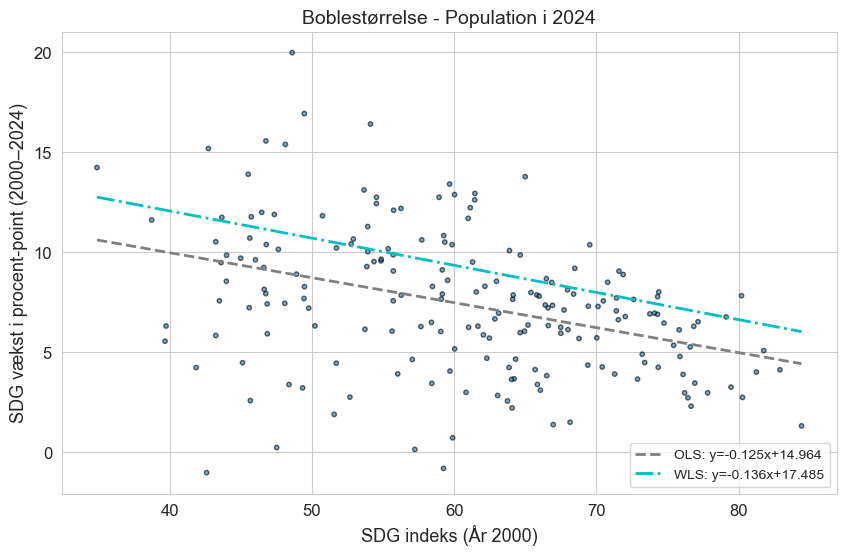

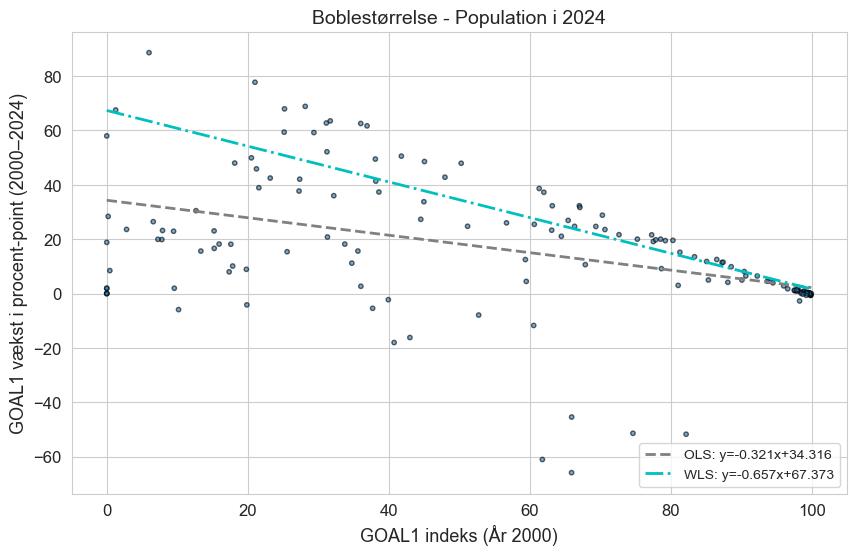

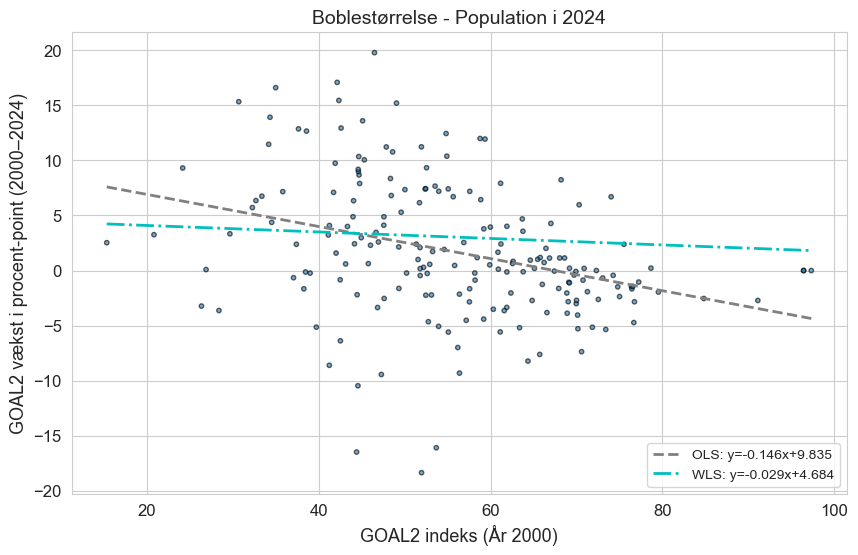

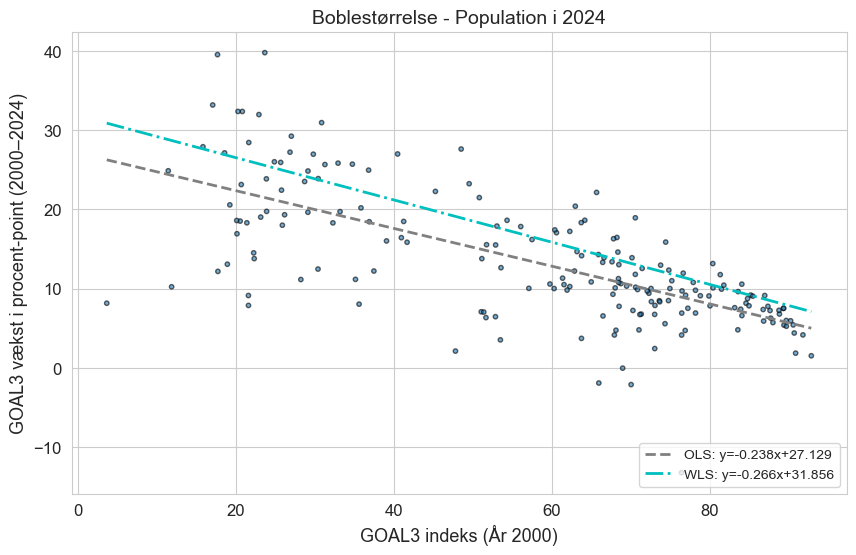

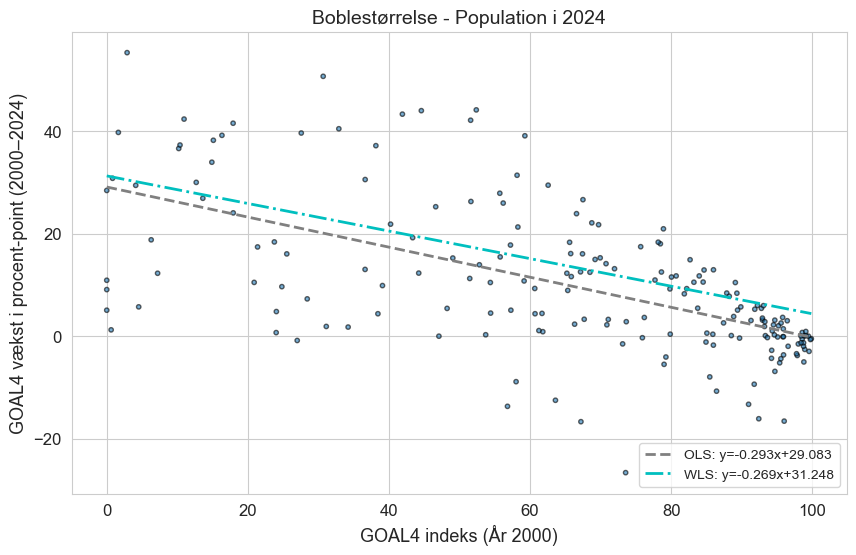

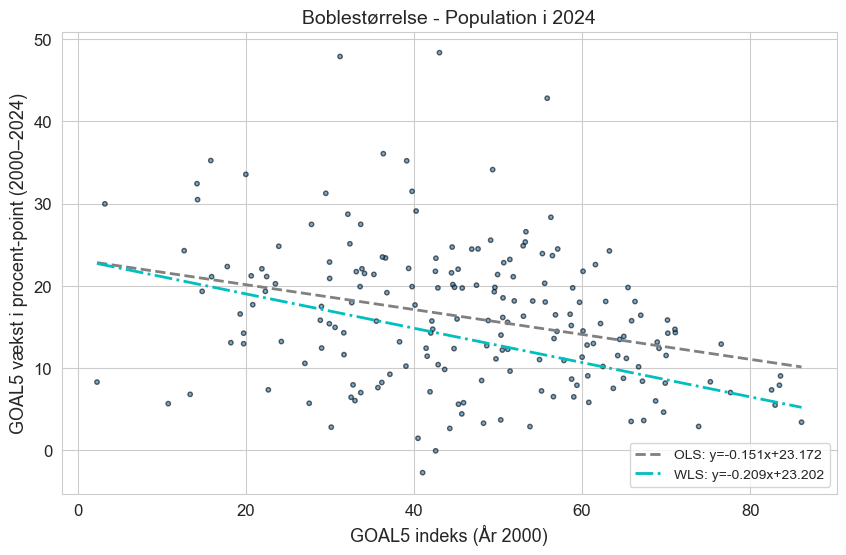

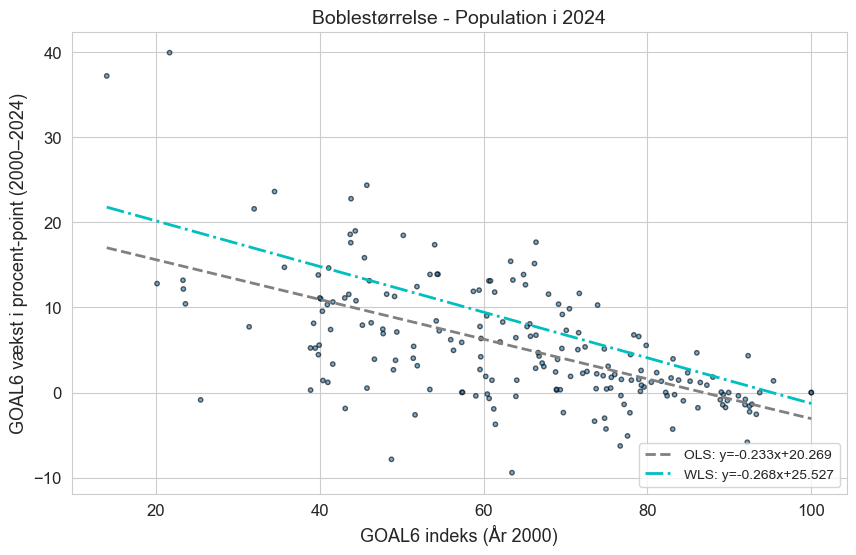

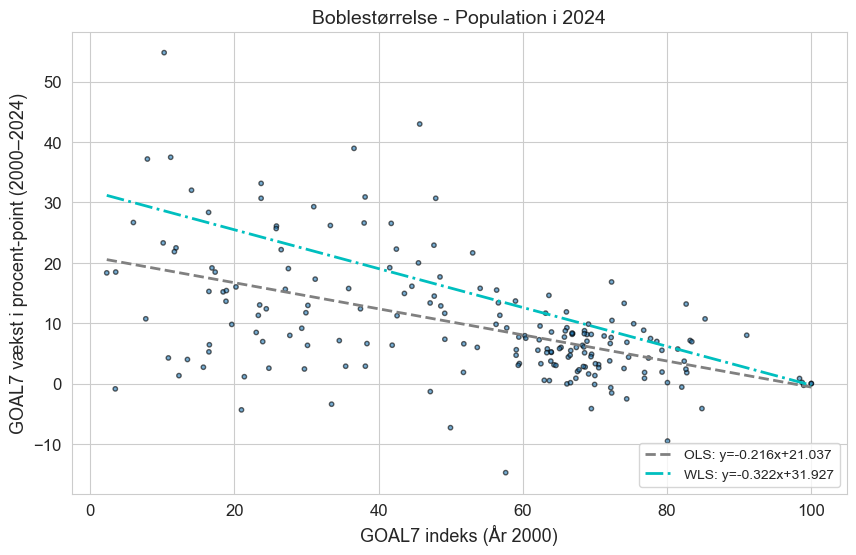

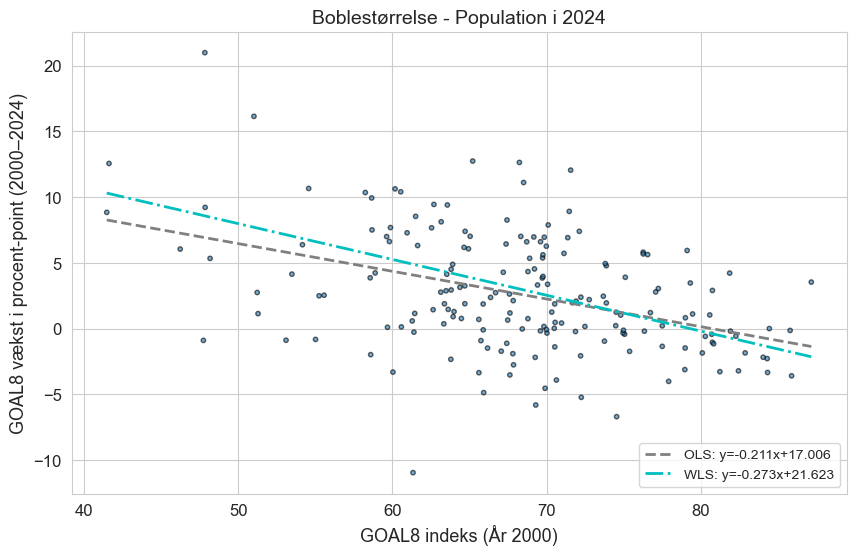

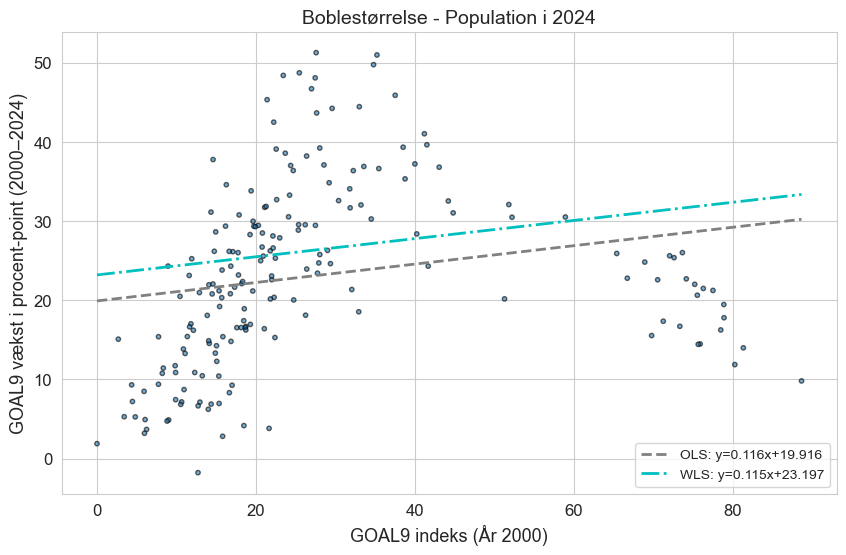

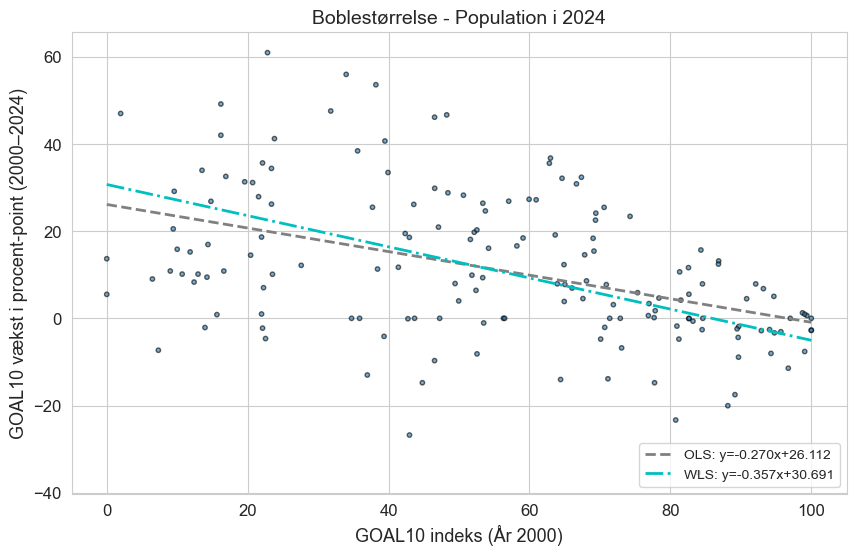

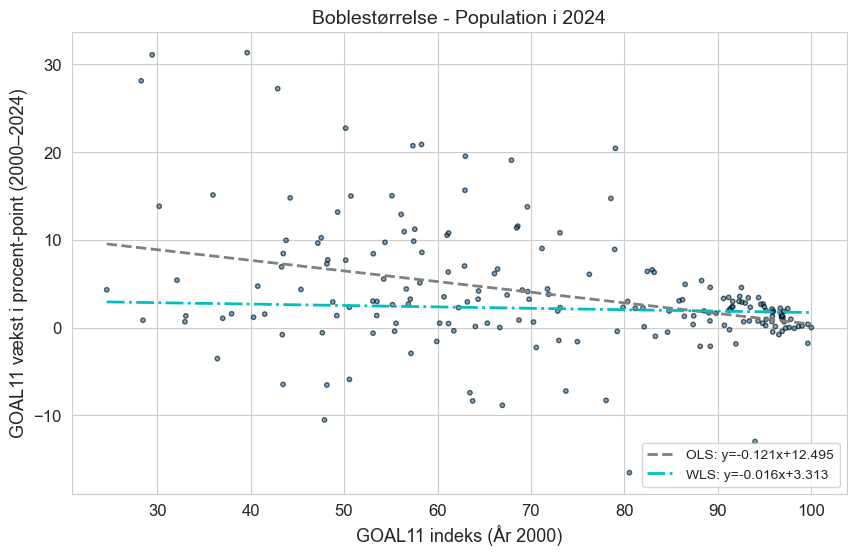

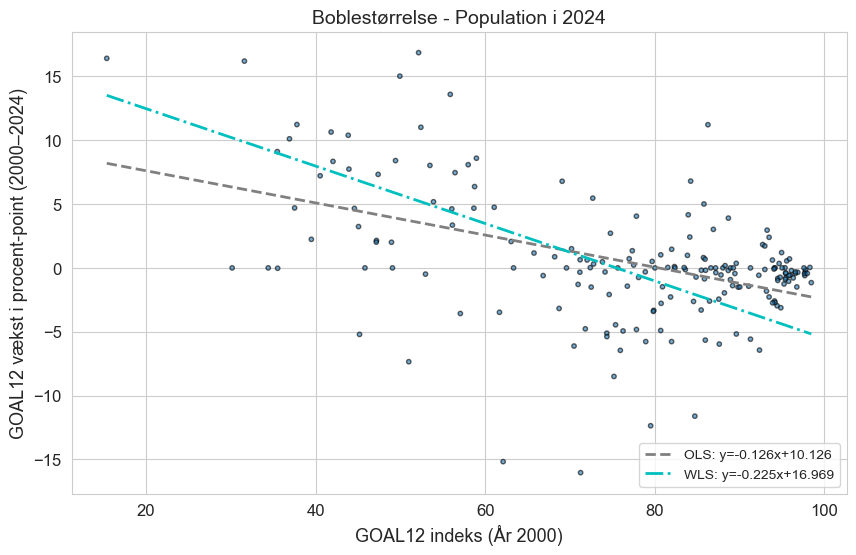

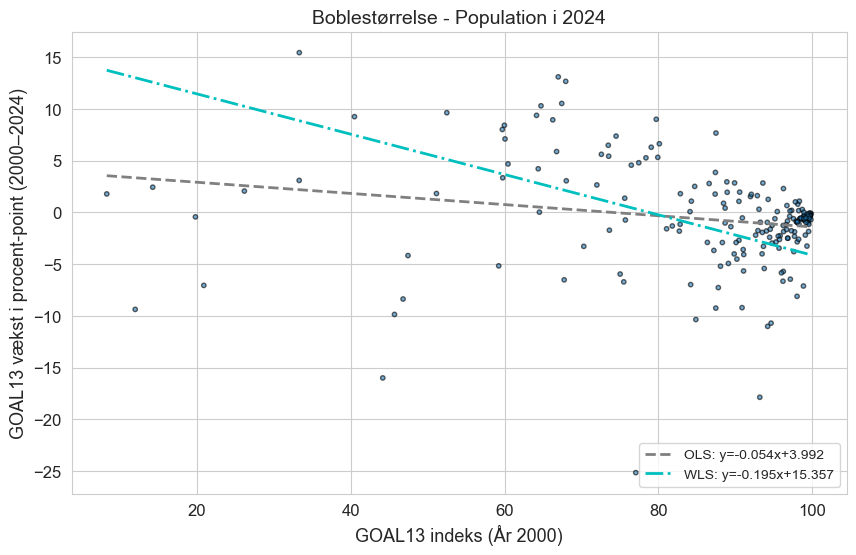

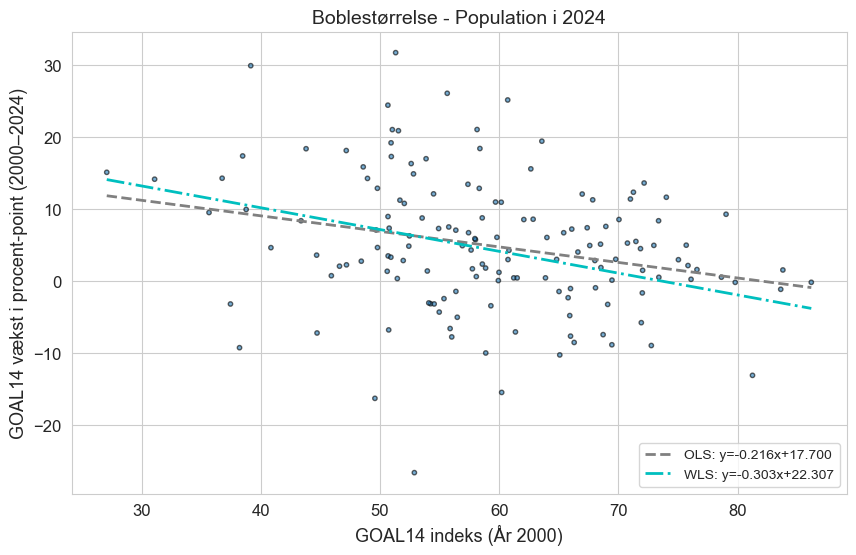

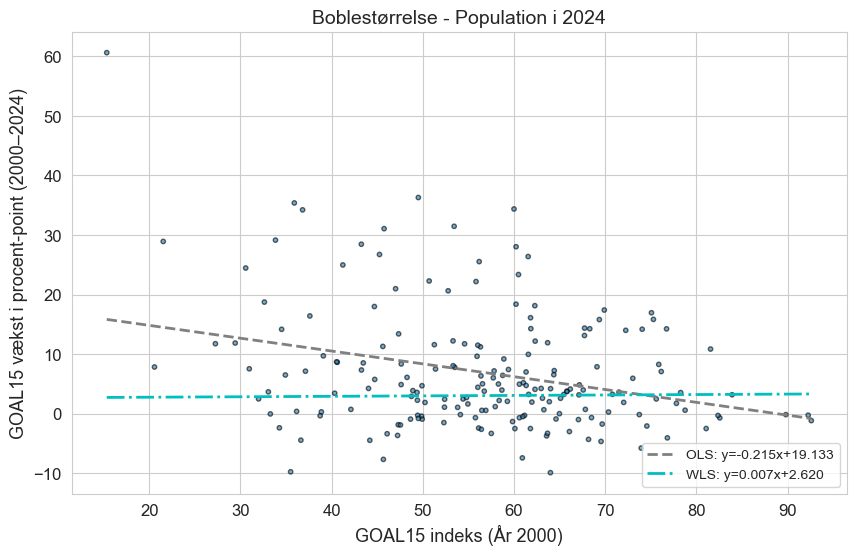

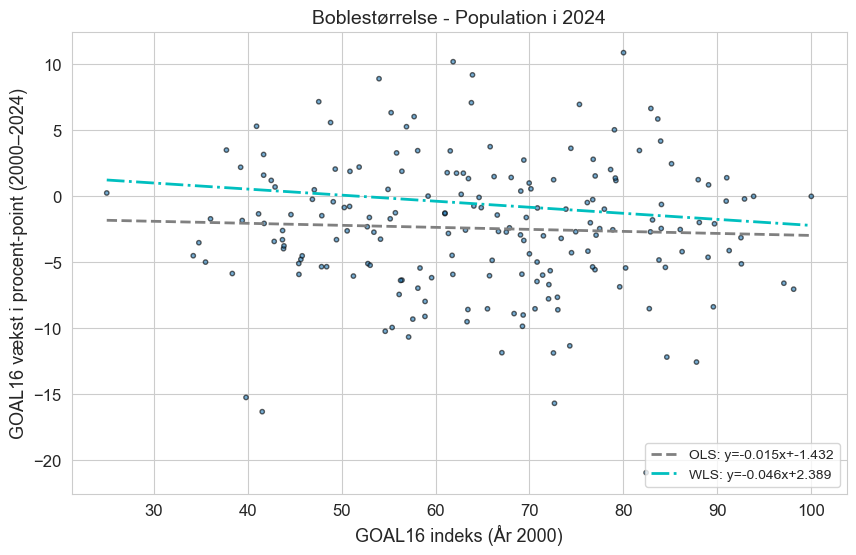

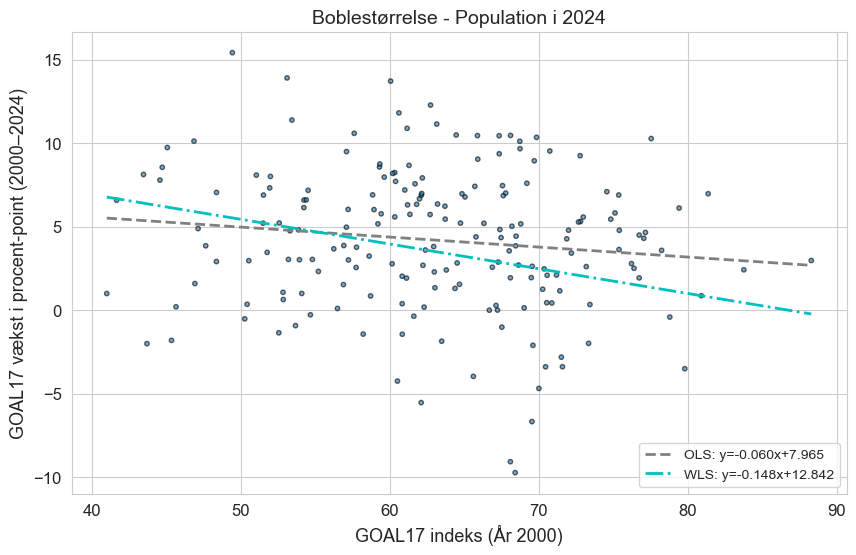

In [11]:
plot_all = True
if plot_all:
    # --- Define which goals to loop over ---
    goals = ["sdgi_s"] + [f"goal{i}" for i in range(1, 18)]

    # Example: highlight some countries
    highlight_ids = [] # "CHN", "IND", "USA","DNK"

    # Loop over all goals and plot
    for g in goals:
        plot_growth_vs_initial(summary,
                            goal=g,
                            highlight_ids=highlight_ids,
                            color_by_region=False,
                            region_to_code=region_to_code,
                            region_categories=region_categories,
                            region_to_color=region_to_color,
                            scale_by_population=False,
                            show_weighted=True,
                            show_confidence_bands=False)


In [12]:
# Region label mapping
region_labels = {
    "Africa": "Africa",
    "OECD": "OECD Countries",
    "LAC": "Latin America & Caribbean",
    "E_Euro_Asia": "Eastern Europe & Central Asia",
    "E_S_Asia": "East & South Asia",
    "MENA": "Middle East & North Africa",
    "Oceania": "Oceania",
    "W_Europe": "Western Europe",
}

# Prepare data
df = summary.reset_index().rename(columns={"id": "country_code"})
df["region_clean"] = df["region"].map(region_labels)

# Region map
fig = px.choropleth(
    df,
    locations="country_code",
    color="region_clean",
    hover_name="country_code",
    color_discrete_sequence=px.colors.qualitative.Set3,
    projection="equirectangular"
)

# Layout: no lakes, no oceans, white land
fig.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        coastlinecolor="rgba(0,0,0,0.4)",
        showland=True,
        landcolor="white",
        showocean=False,
        showlakes=False,
        lakecolor="white",
        showcountries=True,
        countrycolor="rgba(0,0,0,0.3)",
        bgcolor="white",
        lataxis=dict(range=[-60, 85]),
    ),
    template="simple_white",
    paper_bgcolor="white",
    plot_bgcolor="white",
    margin=dict(l=0, r=0, t=40, b=0),

    # --- New legend styling ---
    legend_title_text="",
    legend=dict(
        x=0.02,
        y=0.02,
        xanchor="left",
        yanchor="bottom",
        bgcolor="rgba(255,255,255,0.6)",
        bordercolor="rgba(0,0,0,0.2)",
        borderwidth=1,
        font=dict(size=17)   # <-- 40% bigger legend labels
    )
)

# fig.write_image("../output/map_regions.png", width=1400, height=800, scale=3)
fig.show()
